In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import os
os.listdir()

['.ipynb_checkpoints',
 'AnalystLab Africa Internship Insights.pdf',
 'AnalystLab_EDA_Project.ipynb',
 'cleaned_netflix_titles.csv',
 'cleaned_online_retail.csv']

In [19]:
df = pd.read_csv("cleaned_online_retail.csv")

print(df.shape)

(392692, 10)


In [22]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month'],
      dtype='object')

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


# Online Retail Data Cleaning and Exploratory Data Analysis

## Introduction

This project focuses on cleaning and analyzing the Online Retail dataset using Python and Pandas. The objective was to identify data quality issues, prepare the dataset for analysis, and generate business insights through exploratory data analysis (EDA).

The analysis includes:
- Data loading and inspection
- Handling missing values and duplicates
- Removing invalid transactions
- Revenue analysis
- Trend analysis
- Visualization of key business metrics

# Data Loading

The dataset was imported into Python using the Pandas library. The dataset contains transactional records from an online retail business, including invoice details, products, quantities, prices, customer IDs, and countries.

# Dataset Familiarization

Initial exploration was performed to understand the structure of the dataset, identify data types, review summary statistics, and detect potential data quality issues such as missing values and anomalies.

df.head()
df.info()
df.describe()

## Dataset Structure

Rows: 392,692

Columns: 10

### Numerical Features
- Quantity
- UnitPrice
- Revenue

### Categorical Features
- InvoiceNo
- StockCode
- Description
- CustomerID
- Country

### Date Features
- InvoiceDate
- Month

### Potential Identifiers
- InvoiceNo (Transaction Identifier)
- StockCode (Product Identifier)
- CustomerID (Customer Identifier)

This dataset contains retail transactions including products purchased, quantities, prices, customers, transaction dates, and countries. Revenue was calculated during the cleaning process.

In [23]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (392692, 10)

Data Types:
InvoiceNo        int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
Revenue        float64
Month           object
dtype: object


## Data Validation

To ensure data quality, validation checks were performed to identify:

- Invalid quantities
- Invalid prices
- Missing customer IDs
- Potentially cancelled transactions

These checks help ensure the dataset is suitable for analysis.

In [24]:
print("Negative or Zero Quantities:",
      (df['Quantity'] <= 0).sum())

print("Negative or Zero Prices:",
      (df['UnitPrice'] <= 0).sum())

print("Missing Customer IDs:",
      df['CustomerID'].isnull().sum())

Negative or Zero Quantities: 0
Negative or Zero Prices: 0
Missing Customer IDs: 0


## Cleaning Summary

| Issue Found | Action Taken |
|------------|------------|
| Missing Customer IDs | Removed from customer-level analysis |
| Missing Descriptions | Removed where necessary |
| Duplicate Records | Removed |
| Invalid Transactions | Filtered out |
| Date Formatting Issues | Standardized |
| Revenue Column Missing | Created Revenue Feature |
| Month Extraction Needed | Created Month Column |

# Missing Value Analysis

The dataset was checked for missing values to identify incomplete records that could affect analysis accuracy.

Key findings:
- CustomerID contained a large number of missing values
- Some product descriptions were missing

df.isnull().sum()

# Duplicate Record Detection

Duplicate rows were identified in the dataset. Duplicate transactions can distort analytical results, particularly revenue calculations and transaction counts.

df.duplicated().sum()

# Data Cleaning Process

Several cleaning operations were performed to improve data quality and prepare the dataset for analysis.

The following steps were applied:
- Removed duplicate records
- Removed rows with missing CustomerID values
- Excluded cancelled transactions
- Removed negative or zero quantities
- Removed invalid prices
- Converted InvoiceDate to datetime format
- Created a Revenue column

df = df.drop_duplicates()

## Standardization

The following standardization steps were applied:

- Column names were reviewed for consistency.
- InvoiceDate was converted to datetime format.
- Revenue was calculated as Quantity × UnitPrice.
- Month was extracted from InvoiceDate for trend analysis.
- Data types were verified to ensure compatibility with analysis.

# Feature Engineering

A new Revenue column was created by multiplying Quantity and UnitPrice. This metric was used for revenue-based analysis throughout the project.

df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Revenue Analysis by Country

Revenue was analyzed across countries to identify the highest-performing markets and evaluate geographical sales distribution.

In [77]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

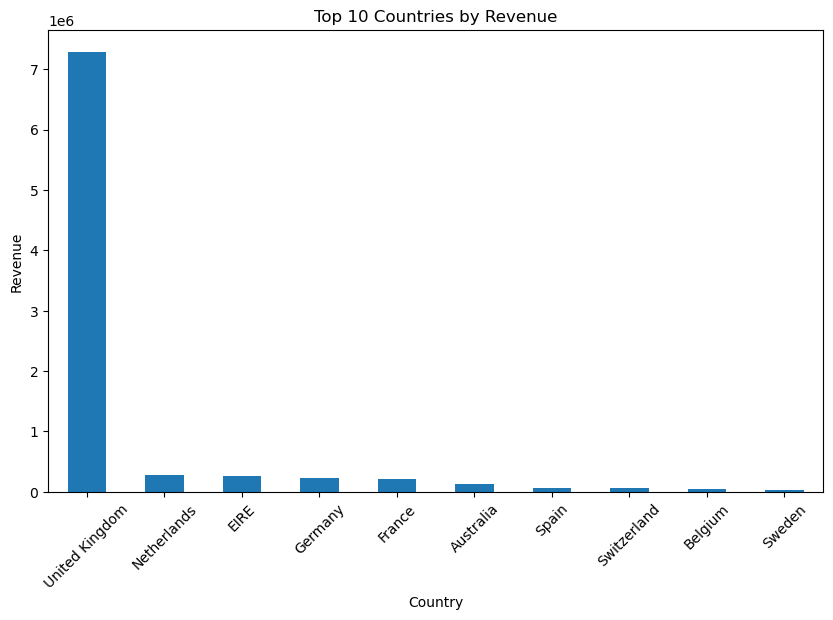

In [45]:
import matplotlib.pyplot as plt

country_revenue.head(10).plot(kind='bar', figsize=(10,6))

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

# Top Products by Revenue

Product-level analysis was conducted to identify the products generating the highest revenue.

In [78]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

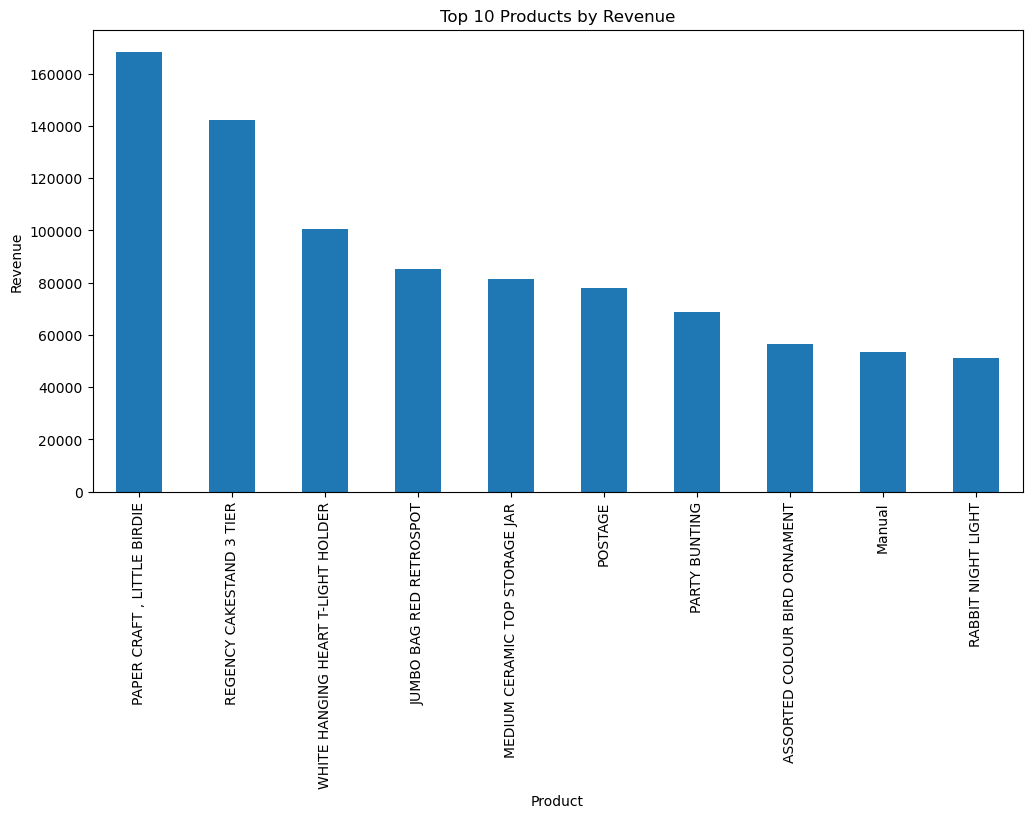

In [46]:
top_products.head(10).plot(kind='bar', figsize=(12,6))

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.xticks(rotation=90)

plt.show()

# Monthly Revenue Trend

Monthly revenue trends were analyzed to observe seasonal patterns and changes in customer purchasing behavior over time.

In [79]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

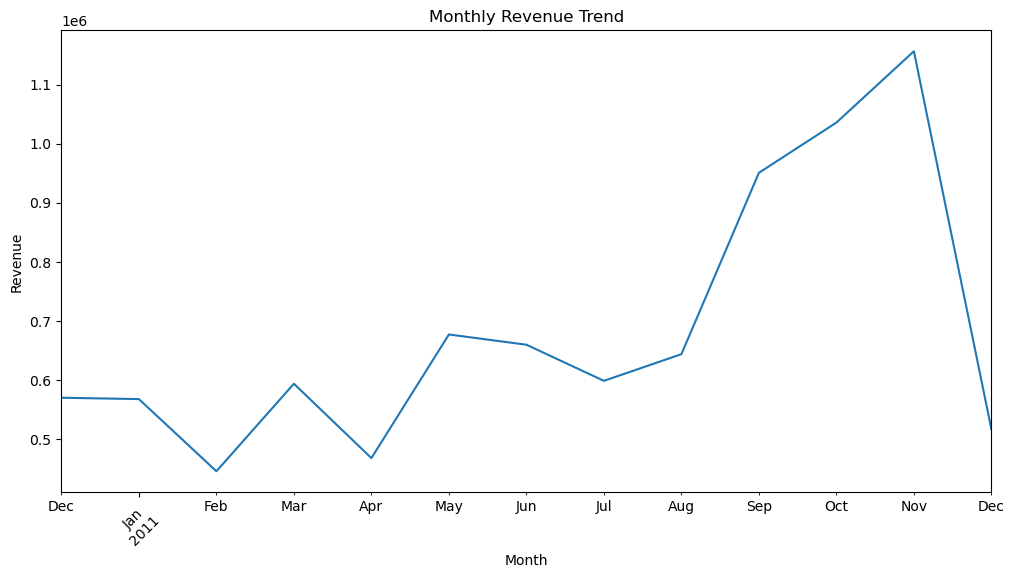

In [47]:
monthly_sales.plot(figsize=(12,6))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

## Customer Spending Analysis

This analysis identifies the customers who generated the highest revenue and helps understand customer purchasing behavior.

In [25]:
customer_spending = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

customer_spending.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

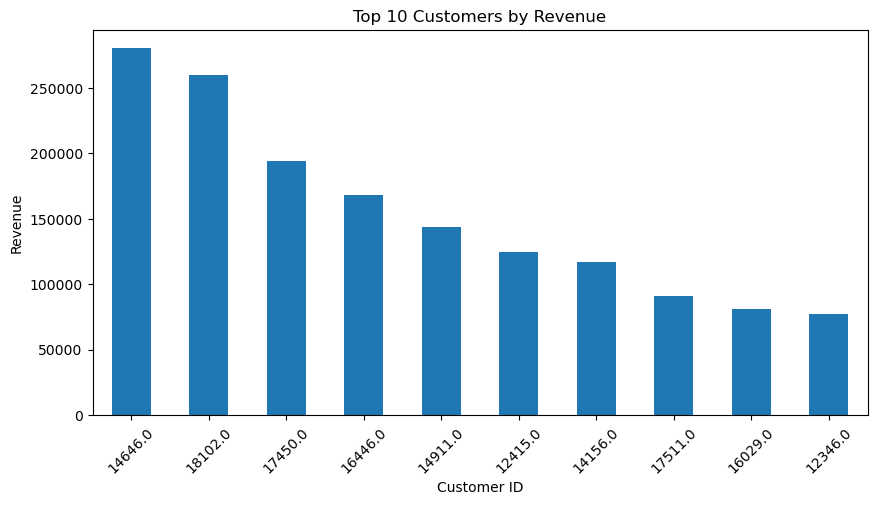

In [26]:
top_customers = customer_spending.head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Insight

A small number of customers contribute a significant portion of total revenue. This suggests that customer retention and loyalty strategies could have a substantial impact on overall business performance.

## Revenue Distribution Analysis

This analysis examines how transaction revenue is distributed across the dataset and identifies the presence of unusually large purchases.

In [27]:
df['Revenue'].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

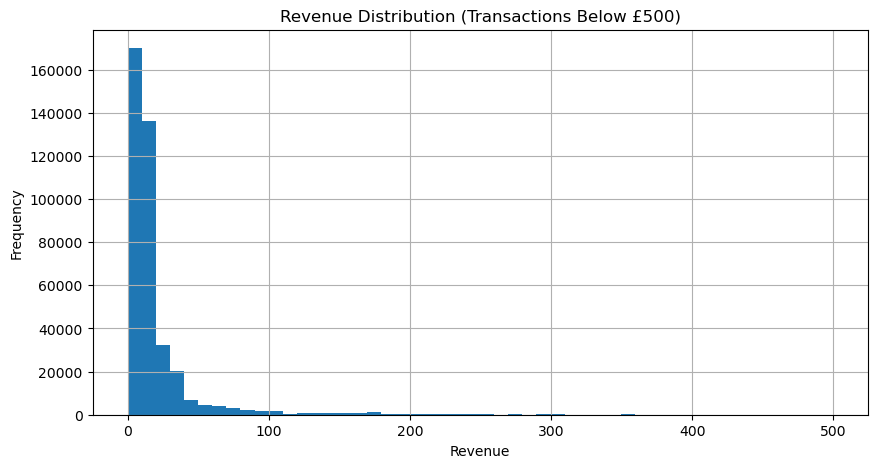

In [30]:
plt.figure(figsize=(10,5))

df[df['Revenue'] < 500]['Revenue'].hist(bins=50)

plt.title('Revenue Distribution (Transactions Below £500)')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()

### Insight

The revenue distribution is highly right-skewed. Most transactions generate relatively small amounts of revenue, while a small number of exceptionally large transactions contribute disproportionately to total sales. This suggests that a few high-value purchases play a significant role in overall business performance.

# Key Insights

1. The United Kingdom generated the highest revenue, significantly outperforming other countries.

2. Revenue increased substantially between September and November 2011, suggesting strong seasonal demand.

3. A small number of products contributed disproportionately high revenue.

4. The dataset contained substantial data quality issues, including missing customer IDs, duplicates, and cancelled transactions.

5. Removing invalid and cancelled transactions improved the reliability of the analysis.

# Conclusion

This project demonstrated the importance of data cleaning and exploratory data analysis in preparing transactional data for business decision-making.

The analysis successfully identified key sales trends, top-performing products, major revenue-generating countries, and important data quality issues.

The cleaned dataset and generated insights provide a stronger foundation for future business analysis and forecasting.

In [81]:
df.to_csv("cleaned_online_retail.csv", index=False)

# Netflix Movies & TV Shows Dataset Analysis

## Introduction

This section focuses on cleaning and analyzing the Netflix Movies and TV Shows dataset. The objective is to explore content distribution, ratings, release trends, and other patterns within Netflix’s catalog.

## Dataset Structure

Rows: [8706]

Columns: [12]

### Numerical Features
- release_year

### Categorical Features
- show_id
- type
- title
- director
- cast
- country
- rating
- duration
- listed_in

### Date Features
- date_added

### Potential Identifiers
- show_id

This dataset contains information about Netflix Movies and TV Shows, including titles, release years, content ratings, countries, genres, and dates added to the Netflix platform.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_netflix_titles.csv")

print(df.shape)

(8706, 12)


# Data Loading

The Netflix dataset was imported into Python using the Pandas library for cleaning and exploratory analysis.

In [33]:
netflix_df = pd.read_csv(
    "cleaned_netflix_titles.csv"
)

print(netflix_df.shape)

(8706, 12)


In [36]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (8706, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


## Data Validation

Data validation was performed to identify missing values, duplicate records, incorrect formats, and inconsistencies that could affect analysis.

Validation checks focused on:

- Missing country information
- Missing director information
- Missing cast information
- Duplicate records
- Date formatting consistency

# Dataset Familiarization

Initial exploration was performed to understand the structure of the dataset, identify data types, and detect missing values.

In [54]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [55]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [56]:
netflix_df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [57]:
netflix_df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [59]:
netflix_df.duplicated().sum()

np.int64(0)

## Cleaning Summary

| Issue Found | Action Taken |
|------------|------------|
| Missing Director Values | Filled/Retained as Unknown |
| Missing Cast Values | Filled/Retained as Unknown |
| Missing Country Values | Filled/Retained as Unknown |
| Duplicate Records | Removed |
| Date Formats | Standardized |
| Column Consistency | Reviewed and Standardized |

# Data Cleaning

Several cleaning operations were performed to improve data quality and prepare the dataset for analysis.

The following steps were applied:
- Removed duplicate records
- Handled missing values
- Standardized date formatting

In [60]:
netflix_df = netflix_df.drop_duplicates()

In [61]:
netflix_df['director'] = netflix_df['director'].fillna('Unknown')

netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

netflix_df['country'] = netflix_df['country'].fillna('Unknown')

netflix_df['rating'] = netflix_df['rating'].fillna('Not Rated')

In [63]:
netflix_df['date_added'] = pd.to_datetime(
    netflix_df['date_added'],
    errors='coerce'
)

In [66]:
netflix_df = netflix_df.dropna(subset=['date_added', 'duration'])

# Content Type Distribution

This analysis compares the number of Movies and TV Shows available on Netflix.

In [68]:
content_type = netflix_df['type'].value_counts()

content_type

type
Movie      6128
TV Show    2578
Name: count, dtype: int64

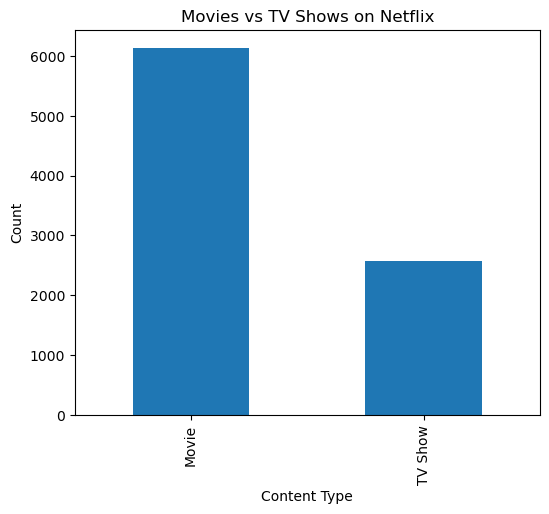

In [69]:
content_type.plot(kind='bar', figsize=(6,5))

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

# Release Year Analysis

This analysis explores the distribution of Netflix content across release years.

In [70]:
netflix_df['release_year'].value_counts().head(10)

release_year
2018    1140
2019    1030
2017    1015
2020     953
2016     878
2021     592
2015     548
2014     343
2013     282
2012     229
Name: count, dtype: int64

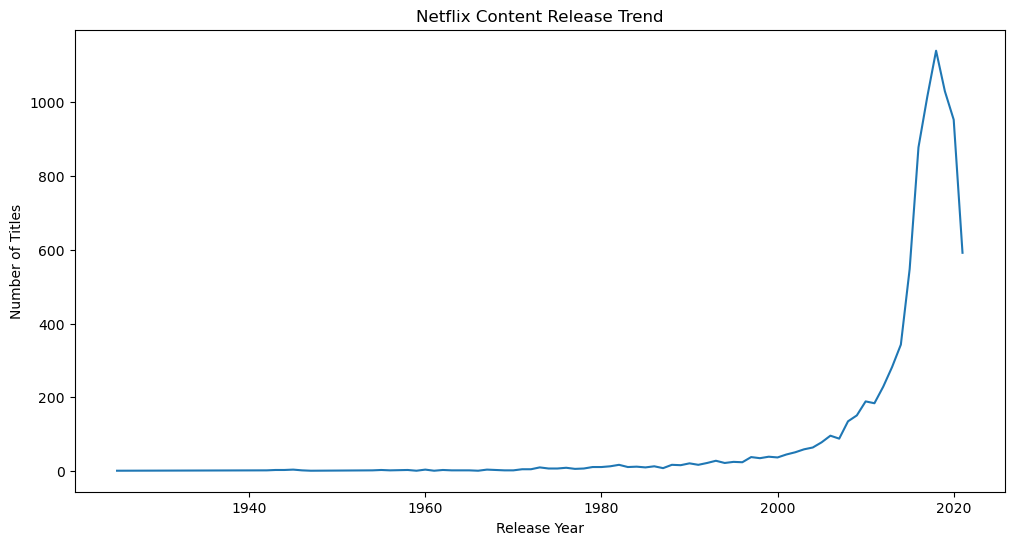

In [71]:
netflix_df['release_year'].value_counts().sort_index().plot(figsize=(12,6))

plt.title('Netflix Content Release Trend')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

# Top Countries by Content Count

This analysis identifies the countries contributing the most Netflix content.

In [72]:
top_countries = netflix_df['country'].value_counts().head(10)

top_countries

country
United States     2775
India              971
Unknown            827
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64

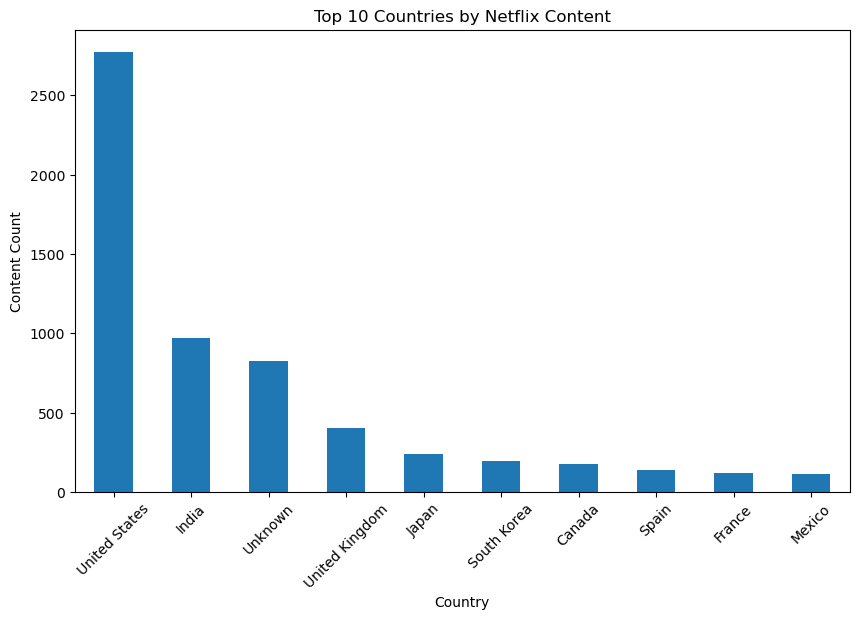

In [73]:
top_countries.plot(kind='bar', figsize=(10,6))

plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Country')
plt.ylabel('Content Count')

plt.xticks(rotation=45)

plt.show()

# Ratings Distribution

This analysis explores the distribution of Netflix content ratings.

In [74]:
ratings = netflix_df['rating'].value_counts()

ratings.head(10)

rating
TV-MA    3183
TV-14    2133
TV-PG     838
R         799
PG-13     490
TV-Y7     330
TV-Y      300
PG        287
TV-G      212
NR         78
Name: count, dtype: int64

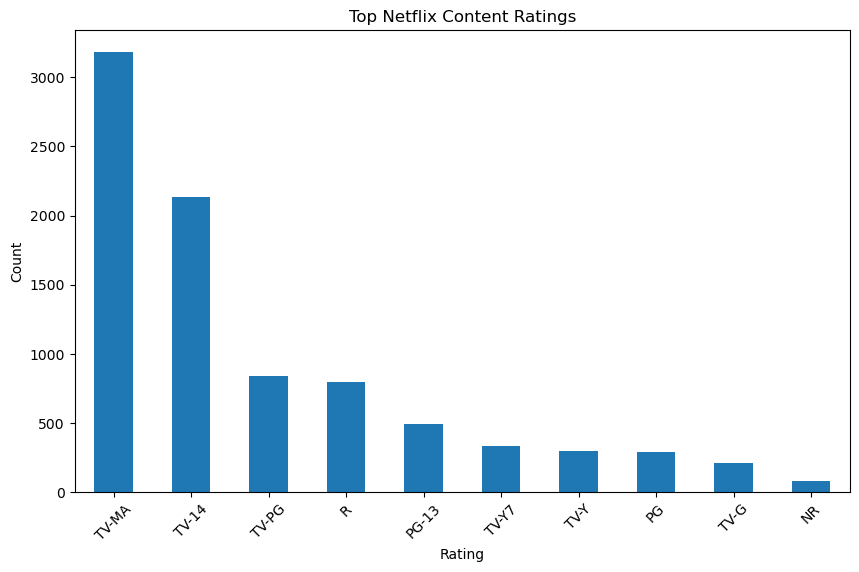

In [75]:
ratings.head(10).plot(kind='bar', figsize=(10,6))

plt.title('Top Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

## Most Common Genres

This analysis identifies the genres/categories most frequently available on Netflix and provides insight into the platform's content strategy.

In [37]:
top_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1328
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


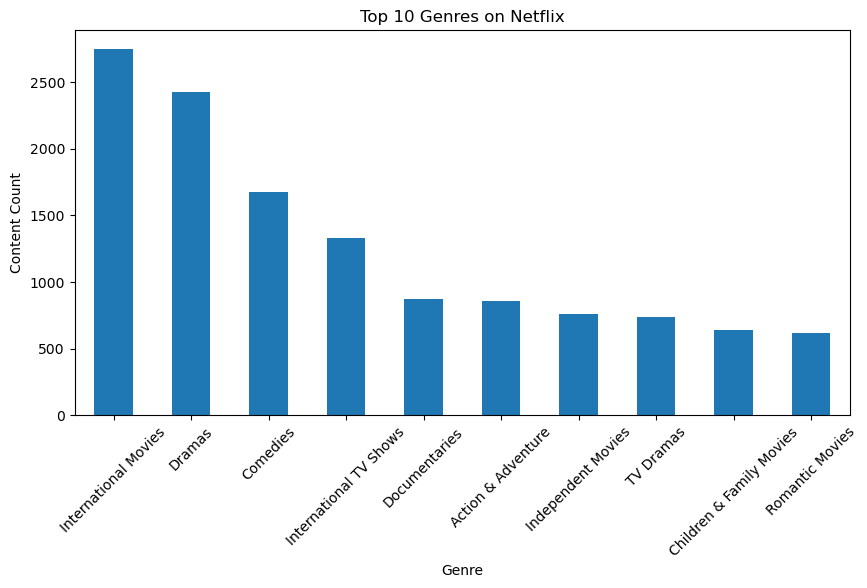

In [38]:
plt.figure(figsize=(10,5))

top_genres.plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Content Count')

plt.xticks(rotation=45)

plt.show()

### Insight

The Netflix content library is concentrated in a small number of genres. Understanding the most common genres helps explain content acquisition priorities and audience preferences on the platform.

# Key Insights

1. Movies make up a larger portion of Netflix content compared to TV Shows.

2. Netflix content increased significantly after 2015, showing rapid platform expansion.

3. The United States contributed the highest amount of content on Netflix.

4. TV-MA and TV-14 were among the most common content ratings, indicating a strong focus on mature audiences.

5. Missing values were common in columns such as director, cast, and country, requiring data cleaning before analysis.

# Conclusion

This analysis explored the structure and distribution of Netflix Movies and TV Shows data. The project demonstrated the importance of data cleaning and exploratory data analysis in understanding media content trends and platform growth patterns.

In [84]:
netflix_df.to_csv("cleaned_netflix_titles.csv", index=False)

# AnalystLab Africa Internship – Insight Report

## Online Retail Dataset Insights

1. The United Kingdom generated the highest revenue, significantly outperforming all other countries.

2. Revenue increased strongly between September and November 2011, indicating seasonal purchasing behavior and possible holiday demand.

3. A small number of products contributed disproportionately high revenue, showing concentration in product performance.

4. The dataset contained major data quality issues including duplicates, missing customer IDs, cancellations, and invalid prices, which required cleaning before analysis.

5. Removing cancelled transactions and invalid records improved the reliability of revenue analysis.

---

## Netflix Dataset Insights

1. Movies represented a larger portion of Netflix content compared to TV Shows.

2. Netflix content production increased significantly after 2015, reflecting rapid platform expansion.

3. The United States contributed the largest amount of content on Netflix.

4. TV-MA and TV-14 were among the most common ratings, indicating strong focus on mature audiences.

5. Data cleaning improved dataset consistency by handling missing values and removing duplicates.

---

## Conclusion

This project demonstrated the importance of data cleaning and exploratory data analysis in preparing datasets for business decision-making. The analyses identified meaningful trends, patterns, and data quality issues across both datasets.